In [451]:
import pennylane as qml
import numpy as np
from pennylane.ops import Prod
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import jax
import jax.numpy as jnp
import jax.random as jrand
import itertools
import time
import math

from optimise import optLoopAdamW
from vqeSetup import TFHamiltonianRevised, exactSolution, ansatz, local_cost_fn, getRho
import warnings
warnings.filterwarnings("ignore", category=np.exceptions.ComplexWarning)

In [455]:
def createDisorderTrainingCases(n, trainingSize, testSize, seed, includeTheseJs=None, paritySorted = None):
    
    total_needed = trainingSize + testSize
    key = jrand.PRNGKey(seed)        

    if includeTheseJs is not None:
        assert (np.unique(jnp.asarray(includeTheseJs), axis=0).shape[0] == includeTheseJs.shape[0]), "Input J's should be unique"
        assert includeTheseJs.shape[0] <= trainingSize, f"too many J's to include for the training size of {trainingSize}"
        includeTheseJs = jnp.array(includeTheseJs)
        assert includeTheseJs.shape[1] == n, "Each included J must have length n"
        selected_set = set(tuple(row.tolist()) for row in includeTheseJs)
        selected = [tuple(row.tolist()) for row in includeTheseJs]
    else:
        selected_set = set()
        selected = []

    remaining = total_needed - len(selected)
    assert remaining >= 0, f"Too many includeTheseJs for trainingSize of {trainingSize}"

    if remaining == 0:
        pass  # already have all needed
    else:
        all_configs = jnp.array(list(itertools.product([-1, 1], repeat=n)))
        if paritySorted is not None: #gives parity ordered listing (parity internally shuffled)
            num_minus_ones = jnp.sum(all_configs == -1, axis=1)
            parity = num_minus_ones % 2
            if paritySorted == 'even':
                sorted_indices = jnp.argsort(parity)
            elif paritySorted == 'odd':
                sorted_indices = jnp.argsort(1 - parity)
            else:
                raise ValueError("paritySorted must be 'even' or 'odd'")

            all_configs = all_configs[sorted_indices]
            split_idx = jnp.sum(parity == (0 if paritySorted == 'even' else 1))
            key, sk1, sk2 = jrand.split(key, 3)
            first = jrand.permutation(sk1, all_configs[:split_idx])
            second = jrand.permutation(sk2, all_configs[split_idx:])
            all_configs = jnp.concatenate([first, second])
        else:
            key, subkey = jrand.split(key)
            all_configs = jrand.permutation(subkey, all_configs)

        available = [tuple(row.tolist()) for row in all_configs if tuple(row.tolist()) not in selected_set]
        for idx in jnp.arange(remaining):
            vec = tuple(available[idx])
            selected.append(vec)
            selected_set.add(vec)
    # else:  # While loop if less than half of cases needed: slow for small n AND wanting most cases in training set. Not used in current version of code
    #     i = 0
    #     while len(selected) < total_needed:
    #         key_i = jrand.PRNGKey(seed + i)
    #         vec = tuple(jrand.choice(key_i, jnp.array([-1, 1]), shape=(n,)).tolist())
    #         if vec not in selected_set:
    #             selected.append(vec)
    #             selected_set.add(vec)
    #         i += 1

    Jmatrix = jnp.array(selected, dtype=jnp.int64)
    return Jmatrix

Investigating hamiltonian structure:

[-2.828427, -2.0]
Group 1 count: 2
Group 2 count: 2
Group 1 example: [-1 -1]
Group 2 example: [ 1 -1]
[-4.0, -3.464102]
Group 1 count: 4
Group 2 count: 4
Group 1 example: [ 1 -1 -1]
Group 2 example: [-1 -1 -1]
[-5.226252, -4.828427]
Group 1 count: 8
Group 2 count: 8
Group 1 example: [-1 -1  1  1]
Group 2 example: [ 1  1 -1  1]
[-6.472136, -6.155367]
Group 1 count: 16
Group 2 count: 16
Group 1 example: [-1  1 -1  1  1]
Group 2 example: [ 1  1  1  1 -1]
[-7.7274069999999995, -7.464102]
Group 1 count: 32
Group 2 count: 32
Group 1 example: [-1  1  1  1  1 -1]
Group 2 example: [ 1  1  1  1  1 -1]
[[0.4999999999999996, 1.0, 0.8190355937288486], [0.44444444444444464, 0.8293446239041954, 0.6760072582241257], [0.3836657388256885, 0.6959029062228063, 0.5595210821027057], [0.3244416838933196, 0.5822810473154263, 0.4616698450394521], [0.2702830299061245, 0.48417878093207434, 0.3792199039766898]]
The lower energy group, defined to be case 1, has fidelities:  [0.4999999999999996, 0.44444444444444464

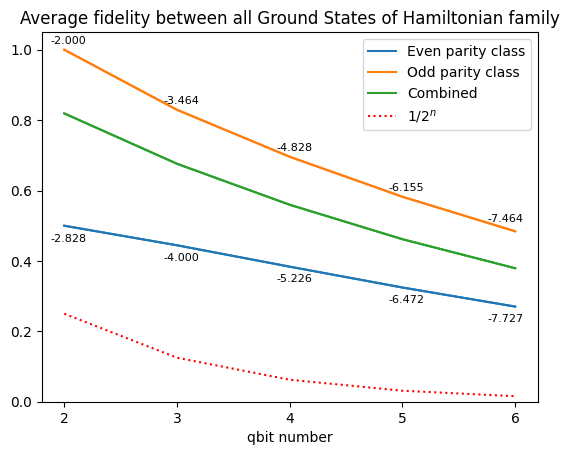

In [ ]:
def count_similar_values(values, tol=1e-5):
    """
    Count how many values in `values` are approximately equal up to a tolerance `tol`, rounding keys to tol precision.
    This is used to count the number of different ground states in the hamiltonian family
    """
    counts = {}
    for v in values:
        key = round(v / tol) * tol
        counts[key] = counts.get(key, 0) + 1
    return counts

def fids(n):
    """
    This finds the intra-fidelity of each class. It does so by finding all ground states, separating them into groups defined by their energy class, then finding the fidelity between all pairs
    """
    h=1
    seed=20
    disorder=True
    exactGSEs = []
    exactGSs = []
    h = jnp.repeat(h,n)
    cases = createDisorderTrainingCases(n,2**n,0,seed,None)
    for casei in cases:    
        ham = TFHamiltonianRevised(casei,h,disorder,(1,n))
        exactGSE=None
        _, exactGSE, GrStates = exactSolution(qml.matrix(ham))
        exactGSEs.append(exactGSE)
        exactGSs.append(GrStates)

    tol = 1e-6
    counts = count_similar_values(exactGSEs, tol=tol) #Identify GSE buckets
    GSE_keys = sorted(counts.keys())  # should be two unique GSEs
    print(GSE_keys)
    cases1, exactGSs1 = [], []
    cases2, exactGSs2 = [], []

    for case, gse, gs in zip(cases, exactGSEs, exactGSs):
        
        key = round(gse / tol) * tol
        tol = 1e-3
        if abs(key - GSE_keys[0]) < tol:
            cases1.append(case)
            exactGSs1.append(gs)
        else:
            cases2.append(case)
            exactGSs2.append(gs)

    print(f"Group 1 count: {len(cases1)}")
    print(f"Group 2 count: {len(cases2)}")
    print(f"Group 1 example: {cases1[0]}")
    print(f"Group 2 example: {cases2[0]}")
    assert len(cases1) + len(cases2) == len(cases)

    def fidel1case(exactGSs):
        fidelity= 0
        count = 0
        for i in range(len(exactGSs)):
            for j in range(i + 1, len(exactGSs)):
                fi = qml.math.fidelity_statevector(exactGSs[i].flatten(), exactGSs[j].flatten())
                fidelity += fi
                count += 1

        average_fidelity = fidelity / count
        return average_fidelity
    
    fidPerGroup = []
    fidPerGroup.append(float(fidel1case(exactGSs1)))
    fidPerGroup.append(float(fidel1case(exactGSs2)))
    fidPerGroup.append(float(fidel1case(exactGSs)))
    return GSE_keys, fidPerGroup, cases1[0]


fidss = []
GSEKeys = []
qbits = np.array([2,3,4,5])
for i in qbits:
    GSE_keys,val,case1eg = fids(i)
    fidss.append(val)
    GSEKeys.append(GSE_keys)
print(fidss)

case1_vals = [x[0] for x in fidss]
case2_vals = [x[1] for x in fidss]
both_vals  = [x[2] for x in fidss]

# def exp_decay(x, a, b, c):
#     return a * np.exp(-b * x) + c

# # Fit the curve
# from scipy.optimize import curve_fit
# params, _ = curve_fit(exp_decay, qbits, case2_vals)
# qbits_extended = np.arange(2, 25)
# fids_fitted = exp_decay(qbits_extended, *params)
# plt.plot(qbits_extended, fids_fitted, '-', label='Fit', color='purple')

labels = ["Even parity class", "Odd parity class"]

if sum(case1eg) % 2 != 0: labels = labels[::-1] # this swaps the order of labels if needed; label must be [case1, case2]
print("The lower energy group, defined to be case 1, has fidelities: ", case1_vals, "and is plotted with label: ", labels[0])
plt.plot(qbits, case1_vals, label=labels[0], color='C0')
plt.plot(qbits, case2_vals, label=labels[1], color='C1') 
plt.plot(qbits, both_vals,  label='Combined',   color='C2') 
plt.plot(qbits, 1/2**qbits, label = r"$1/2^{n}$", linestyle = 'dotted', color = 'red')
for i, x in enumerate(qbits):
    if x == qbits[-1]:
        plt.text(x - 0.25, case2_vals[i] + 0.02, f"{GSEKeys[i][1]:.3f}", fontsize=8, ha='left', va='bottom')
        plt.text(x - 0.25, case1_vals[i] - 0.05, f"{GSEKeys[i][0]:.3f}", fontsize=8, ha='left', va='bottom')
    else:
        plt.text(x - 0.12, case2_vals[i] + 0.01, f"{GSEKeys[i][1]:.3f}", fontsize=8, ha='left', va='bottom')
        plt.text(x - 0.12, case1_vals[i] - 0.05, f"{GSEKeys[i][0]:.3f}", fontsize=8, ha='left', va='bottom')


plt.legend()
plt.plot(qbits,fidss)
plt.title('Average fidelity between all Ground States of Hamiltonian family')
plt.xlabel('qbit number')
plt.xticks(qbits)
plt.ylim(0,1.05)
plt.show()

# diff =  fids_fitted/(1/2**qbits_extended)
# print(diff)
# plt.plot(qbits_extended, diff, '-', label='Fit', color='purple')
# plt.yscale('log')
# plt.show()

#count_similar_values(exactGSEs, tol=1e-12)

Functions for Graphing 2 (Specific descent, final state statistics, circuit draw):

In [457]:
def checkVariance(finalVarParams,J,n,numLayers,ham,disorder):
    def square_hamiltonian(ham):
        coeffs_squared = []
        observables_squared = []

        for i in range(len(ham.ops)):
            for j in range(len(ham.ops)):
                obs_i = ham.ops[i]
                obs_j = ham.ops[j]
                coeff = ham.coeffs[i] * ham.coeffs[j]
                product = Prod(obs_i, obs_j).simplify()
                coeffs_squared.append(coeff)
                observables_squared.append(product)
        return qml.Hamiltonian(coeffs_squared, observables_squared)

    hamSquared = square_hamiltonian(ham)
    expH = local_cost_fn(finalVarParams,J,n,numLayers,ham,disorder)
    expH2 = local_cost_fn(finalVarParams,J,n,numLayers,hamSquared,disorder) #raises complexwarning, supressed above
    var =  expH2 - expH**2
    print("Variance of final state is: ",var)

In [458]:
def checkStateMatch(finalVarParams,J,h,n,numLayers,ham,exactProbs,exactStates,disorder,drawProbs):
    
    variaRho = getRho(finalVarParams,J,n,numLayers,ham,disorder)
    variaProbs= jnp.real(jnp.diag(variaRho))
    fidelity = None

    if exactStates.shape[1] == 1:
        exactRho = jnp.outer(exactStates.flatten(), jnp.conj(exactStates.flatten()))
        fidelity = qml.math.fidelity(exactRho,variaRho)
    else:
        print("Degen GS, no fidelity computed")
    
    if drawProbs:
        sorted_indices = np.argsort(-(variaProbs + exactProbs))
        top_indices = sorted_indices[:10]
        labels = [format(i, f"0{n}b") for i in range(2**n)]# Filtering top probabilities and labels

        top_labels = [labels[i] for i in top_indices]
        top_variaProbs = variaProbs[top_indices]
        top_exactProbs = exactProbs[top_indices]

        x = np.arange(len(top_labels))
        width = 0.4

        fig, ax = plt.subplots()
        ax.bar(x - width/2, top_variaProbs, width, label="Variational")
        ax.bar(x + width/2, top_exactProbs, width, label="Exact")

        ax.set_yscale("log")
        ax.set_xticks(x)
        ax.set_xticklabels(top_labels, rotation=45)
        ax.set_ylabel("Probability (log scale)")
        plt.title("Probability comparison")
        ax.legend()
        plt.show()
    return fidelity
    

In [459]:
def checkSpecificRun(numLayers, n, seed=42, lrs=None, h=1, J=1, randomJ=False, disorder=False, initParams= None,drawCircuit=False,drawDescent=False,drawProbs=False,returnParams=False):
    if disorder == False:
        assert randomJ == False
        
    if randomJ:
        rand_bits = jrand.randint(jrand.PRNGKey(seed), shape=(n,), minval=0, maxval=2)
        J = 2 * rand_bits - 1

    print("h,J: ",h,J)
    ham = TFHamiltonianRevised(J,h,disorder,(1,n))
    _, exactGSE, exactGSs = exactSolution(qml.matrix(ham)) #exactGSs is already normalised here

    energies, finalVarParams, converged = optLoopAdamW(n,numLayers, J, h, ham, lrs, 1, disorder, seed=seed, returnOnlyEf=False, prevLayersParams = initParams, disorderCases=None)
    energies = np.array(energies.flatten()[0])
    errors = np.abs((energies - exactGSE)/exactGSE)

    if drawDescent:        
        plt.subplot(1,2,1)
        plt.plot(np.arange(len(energies)), energies)
        plt.title(f"{n} qbits, {numLayers} layers, h={h[0]},J={J[0]}") if not disorder else plt.title(f"{n} qbits, {numLayers} layers, disordered J")
        plt.axhline(y = exactGSE, color = 'g', linestyle = '--', alpha = 0.8) 
        plt.text(0.35, 0.8, f"Converged = {converged}", fontsize=7,
            bbox=dict(facecolor='yellow', alpha=0.5, edgecolor='black', boxstyle="round,pad=0.5"),
            ha='center', va='center', transform=plt.gcf().transFigure)
        plt.xlabel('Iteration')
        plt.ylabel('Energy')

        plt.subplot(1,2,2)
        label = "Not inited" if initParams is None else "Inited"
        plt.semilogy(errors, linestyle='-',label=label)
        plt.title("Log plot of Error to GS")
        plt.xlabel("Iteration")
        plt.ylabel("Log Error")
        plt.legend()

    x = np.abs(exactGSs)**2
    exactProbs = np.sum(x,axis=1) / exactGSs.shape[1] ## Dirac, eg 00,01,10,11. This line deals with degenerate GSs: summed into 1 vector, and is a prob so sums to 1

    if drawCircuit:
        qml.drawer.use_style("pennylane")
        fig, ax = qml.draw_mpl(ansatz,style="pennylane")(J,n,finalVarParams[:,:,:,0,0],numLayers,disorder) 

    fidelity = checkStateMatch(finalVarParams[:,:,:,0,0],J,h,n,numLayers,ham,exactProbs,exactGSs,disorder,drawProbs) #note the last 2 dimensions of finalVarParams are size 1 here
    checkVariance(finalVarParams[:,:,:,0,0],J,n,numLayers,ham,disorder)

    if returnParams:
        return finalVarParams, fidelity, errors
    else:
        return fidelity, errors

Functions for Graphing 3 (layer or lr run):

In [460]:
def plotLayerRuns(Efs, convergedMatrix, exactGSE, n, layerList, J, h, disorder,keepPrevLayersParams, Global):
    
    cmap = cm.get_cmap('tab10')  # This is a colour map to see same seeds
    colour_dict = {v: cmap(v % 8) for v in list(range(Efs.shape[0]))}  # wraparound if > 8
    numRuns = Efs.shape[3] #whether we wanted to do the prev layer initialisation runs too. either 1 or 2

    for runidx in range(numRuns):
        lineStyle = ['solid', 'dotted'][runidx] if numRuns == 2 else ('dotted' if keepPrevLayersParams == "yes" else 'solid')

        for seedidx in range(Efs.shape[0]):
            Ef_values = Efs[seedidx,:,0,runidx] # here we assume we only have 1 lr
            baseline = exactGSE if not Global else exactGSE[seedidx] # handles having either one GSE for all seeds (local run), or different, where seed means each J in disorderCases
            ERelatifDiff = np.abs((Ef_values - baseline) / baseline)
            color, alpha = ('black', 1) if Global and seedidx == 0 else (colour_dict[seedidx], 0.4)
            plt.plot(layerList, ERelatifDiff, label=f'seed {seedidx}',color=color,linestyle=lineStyle,alpha = alpha)

            convergence_status = convergedMatrix[seedidx,:,0,runidx]
            plt.scatter(layerList[convergence_status], ERelatifDiff[convergence_status], color='purple', marker='o', s=50)
        
        if not Global: # ie we have one exactGSE for all seeds. the mean is already done above if its global
            mean_across_seeds = np.mean(Efs[:,:,0,runidx], axis=0)
            plt.plot(layerList, np.abs((mean_across_seeds - exactGSE) / exactGSE), label=f'Average across seeds', color='black', linestyle=lineStyle)
            if len(layerList) == 1: print("Mean across seeds Ef is: ", np.abs((mean_across_seeds - exactGSE) / exactGSE))

    plt.title(f'J = {J}, h={h}, {n} qbits') if not disorder else plt.title(f'Disordered J, {n} qbits, Global = {Global}')
    plt.xlabel('layer num')
    plt.xticks(layerList)
    plt.ylabel('Erel')
    plt.yscale('log')
       
    sns.despine()
    plt.legend().remove()
    plt.tight_layout()
    plt.show()

In [461]:
def plotlrRuns(Efs, convergedMatrix, exactGSE, n, layerList, lrList, J, h, disorder,keepPrevLayersParams,Global):
    cmap = cm.get_cmap('tab10')  # This is a colour map to see same seeds
    colour_dict = {v: cmap(v % 8) for v in list(range(Efs.shape[1]))}  # wraparound if > 8
    lineStyle = 'dotted' if keepPrevLayersParams == "yes" else 'solid'

    for layeridx in range(len(layerList)):
        for seedidx in range(Efs.shape[0]):
            Ef_values = Efs[seedidx, layeridx, :, 0] # assumed only 1 run done, ie keepPrevLayersParams = "no" or "yes"
            baseline = exactGSE if not Global else exactGSE[seedidx]
            ERelatifDiff = np.abs((Ef_values - baseline) / baseline)
            alpha = 1 if Global and seedidx == 0 else 0.25
            plt.plot(lrList, ERelatifDiff,label=f'{layerList[layeridx]} Layers',color = colour_dict[layeridx], linestyle=lineStyle, alpha = alpha)

            convergence_status = convergedMatrix[seedidx, layeridx, :, 0]
            plt.scatter(lrList[convergence_status], ERelatifDiff[convergence_status], color='purple', marker='o', s=50)

        if not Global: 
            mean_across_seeds = np.mean(Efs[:,layeridx,:,0], axis=0)
            plt.plot(lrList, np.abs((mean_across_seeds - exactGSE) / exactGSE), label=f'Average across seeds',color = colour_dict[layeridx], linestyle=lineStyle)

    plt.title(f'J = {J}, h={h}, {n} qbits') if not disorder else plt.title(f'Disordered J, {n} qbits, Global = {Global}')
    plt.xlabel('lr')
    plt.xticks(lrList)
    plt.ylabel('Erel')
    plt.yscale('log')
    plt.xscale('log')
    handles, labels =  plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))  # keeps last occurrence
    plt.legend(unique.values(), unique.keys())

    sns.despine()
    plt.tight_layout()
    plt.show()



In [ ]:
def oneRun(numSeeds, n, ham, layerList, J,h, seed, lrs, keepPrevLayersParams, disorder, disorderCases, Global):
    '''the purpose of this function is to allow for the option of doing "both" initprev and not. it means we can take the result from this and add a dimension to the matrices
    '''
    Efs = np.zeros(shape=(numSeeds,len(layerList),len(lrs))) # matrix of final energies used in plotting
    convergedMatrix = np.zeros(shape=(numSeeds,len(layerList),len(lrs)), dtype=bool)

    if Global: numSeeds=1 #tells the optLoopAdamW loop to only do 1 descent, but it will return a shape of global, then all locals
    for layeridx, layersi in enumerate(layerList):
        startT = time.time()
        if keepPrevLayersParams and layeridx > 0: # only runs for after the first layer, since the first layer is always random
            energies, finalVarParamsMatrix, converged = optLoopAdamW(n, layersi, J, h, ham, lrs, numSeeds, disorder, seed=seed, prevLayersParams = finalVarParamsMatrix, disorderCases = disorderCases)
        else:
            energies, finalVarParamsMatrix, converged = optLoopAdamW(n,layersi, J, h, ham, lrs, numSeeds, disorder, seed=seed, disorderCases = disorderCases)
        print("energies:", np.array(energies))
        endT = time.time()
        m, s = divmod(endT - startT, 60)
        Efs[:,layeridx,:] = np.array(energies) # "energies" is Ef for: seeds by lrs matrix. if global, seeds <- seeds+1, since you get the global Ef too in position 0.
        convergedMatrix[:,layeridx,:] = converged[:,:]
        print(f"Completed layer {layersi}. Time: {int(m)}m {s:.2f}s")

    return Efs,convergedMatrix,finalVarParamsMatrix

In [463]:
def layrOrLrRuns(numSeeds, n, layerList, J, h, seed, runType, lrs=None, keepPrevLayersParams="no", disorder=False, Global = False):
    assert runType in ["layer", "lr"], "runType must be either 'layer' or 'lr'"
    assert keepPrevLayersParams in ["no", "yes", "both"], "keepPrevLayersParams must be either 'no', 'yes' or 'both'"
    def run_and_expand(keep):
        Efs, convergedMatrix,_ = oneRun(numSeeds, n, ham, layerList, J, h, seed, lrs, keep, disorder, disorderCases, Global)
        Efs = np.expand_dims(Efs, axis=3)
        convergedMatrix = np.expand_dims(convergedMatrix, axis=3)
        return Efs, convergedMatrix
    
    h = jnp.repeat(h,n)
    disorderCases = None
    if Global: #this means you want to have the seeds all go at once, optimising all <Hi>. this is instead of doing each individually (original and main method of using this function)
        disorderCases = createDisorderTrainingCases(n, numSeeds, 0, seed, None)
        print(disorderCases)
        exactGSE = []

        for Jidx,J in enumerate(disorderCases):
            ham = TFHamiltonianRevised(J,h,disorder,(1,n))
            _, exactGSEi, _ = exactSolution(qml.matrix(ham))
            exactGSE.append(exactGSEi)
        exactGSEglob = np.mean(exactGSE)
        exactGSE.insert(0, exactGSEglob)
        exactGSE = np.array(exactGSE) #now its an array instead of a scalar as in the non Global case. each descent is compared so its corresponding J
        if np.allclose(exactGSE, exactGSE[0], atol=1e-6): #this ensures that al the J's are not in the same energy category, for *mixed* training, errors go from 10e-6 to 10e-2.
            print("All in same energy category, aborting")
            return

        numSeeds = numSeeds+1 # this is used to have the global and all the local descents
        ham=None #ham not used at all in global case. Can be set to anything
    else:
        rand_bits = jrand.randint(jrand.PRNGKey(seed), shape=(n,), minval=0, maxval=2)
        J = 2 * rand_bits - 1 if disorder else jnp.repeat(J,n)
        print(h,J)
        ham = TFHamiltonianRevised(J,h,disorder,(1,n))
        print(ham)
        exactGSE=None
        _, exactGSE, _ = exactSolution(qml.matrix(ham)) 

    print("numSeeds:", numSeeds, ". disorderCases:", disorderCases, "exactGSE (global first if global run):", exactGSE) #now these 3 parameters are properly set for the runs

    if keepPrevLayersParams == "both":
        Efs1, converged1 = run_and_expand(False)
        Efs2, converged2 = run_and_expand(True)
        Efs = np.concatenate((Efs1, Efs2), axis=3)
        convergedMatrix = np.concatenate((converged1, converged2), axis=3)
    else:
        Efs, convergedMatrix = run_and_expand(keepPrevLayersParams == "yes") #if its no this will be false
    if runType == "layer":
        plotLayerRuns(Efs, convergedMatrix, exactGSE, n, layerList, J, h, disorder, keepPrevLayersParams, Global)
    elif runType == "lr":
        plotlrRuns(Efs, convergedMatrix, exactGSE, n, layerList, lrs, J, h, disorder, keepPrevLayersParams, Global)

Cell to run above code:

In [464]:
layerList = np.array([5,6,7])
lrList = np.array([0.001])

n=6
#fidel,_ = checkSpecificRun(5,n,seed=48,h=jnp.repeat(1,n),J=1,randomJ=True,disorder=True,drawCircuit=False,drawProbs=True,drawDescent=True,initParams=None)
#print("fidel is: ", fidel)

# layrOrLrRuns(2,4, layerList, 1, 1, 42, "lr", lrs=np.array([0.001,0.005]), keepPrevLayersParams="yes", disorder=True)
#    numSeeds, n, layerList, J, h, seed, runType, lrs=None, keepPrevLayersParams="no", disorder=False
''' layrOrLrRuns: this is a hyperparameter testing function. layer or lr on x axis choice. fixed number qbits and h,J unless disorder=True.
    Assumptions to run this function:
     If doing layer runs, you have only one lr, eg [0.01]. You may choose keepPrevLayersParams = "no", "yes" or "both". keepingPrevParams always plots as dotted lines.
     If doing lr runs, you may in fact have multiple layers, but set keepPrevLayersParams = "no" or "yes", its too messy otherwise.
     (note J param is overwritten if disorder=True)
     KeepingPrevLayersParams is only relevant for more than 1 layer, and it does not need to be incremental: eg layerList could = [1,4,5]; for 4 layers, it would init with best params of 1st layer
     new functionality for layer runs: global boolean value means that the numSeeds are all done at once, ie theyre evaluated using the global function, all at once.
     '''

# n=3
# qml.drawer.use_style("pennylane")
# fig, ax = qml.draw_mpl(ansatz, style="pennylane")(jnp.repeat(1,n), n, np.zeros_like(np.zeros((n, 6, 2))), 2, disorder=True)

' layrOrLrRuns: this is a hyperparameter testing function. layer or lr on x axis choice. fixed number qbits and h,J unless disorder=True.\n    Assumptions to run this function:\n     If doing layer runs, you have only one lr, eg [0.01]. You may choose keepPrevLayersParams = "no", "yes" or "both". keepingPrevParams always plots as dotted lines.\n     If doing lr runs, you may in fact have multiple layers, but set keepPrevLayersParams = "no" or "yes", its too messy otherwise.\n     (note J param is overwritten if disorder=True)\n     KeepingPrevLayersParams is only relevant for more than 1 layer, and it does not need to be incremental: eg layerList could = [1,4,5]; for 4 layers, it would init with best params of 1st layer\n     new functionality for layer runs: global boolean value means that the numSeeds are all done at once, ie theyre evaluated using the global function, all at once.\n     '

Final 2 plots functions:

In [465]:
def train(numLayers, n, seed=42, drawCircuit=False, drawDescent=True, drawProbs=False, disorderCases=None):
    '''This training function calls the optimisation function, passing the disorder cases, and specifying 1 seed; training always means taking all disorder cases
    at once, optimising them at the same time. therefore only 1 gradient descent is run, just with a more complicated cost function (ie 1 seed only).
    It returns the energy descents of the global (the cost function), and also the local energies (each case in disorder cases), which are hopefully optimised through
    the global cost function. 
    It returns the global descent, converted to an error of its goal, the mean of ground states of those in its training set (Disorder cases). 
    It returns the  final parameters for the circuit at the end of the optimisation.    
    '''

    disorder=True
    h = jnp.repeat(1,n)
    exactGSEs = np.zeros(shape = len(disorderCases))
    energies, finalVarParams, converged = optLoopAdamW(n,numLayers, None, None, None, None, 1, disorder, seed=seed, returnOnlyEf=False, disorderCases=disorderCases)
    #here energies is a matrix of full descents, first row is global descent, second and below are all the locals (as many rows as in disorderCases)
    globalDescent = energies[0].reshape(-1)[0]
    localDescents = energies[1:].reshape(-1)

    for Jidx,J in enumerate(disorderCases):
        ham = TFHamiltonianRevised(J,h,disorder,(1,n))
        _, exactGSE, exactGSs = exactSolution(qml.matrix(ham)) #exactGSs is already normalised here
        exactGSEs[Jidx] = exactGSE

    if drawDescent:        
        numDisorder = disorderCases.shape[0]
        steps = [len(desc) for desc in localDescents]

        colors = cm.viridis(np.linspace(0, 1, numDisorder))
        fig, axs = plt.subplots(1, 2, figsize=(10, 8), sharex=True)

        # Plot 1
        for i in range(numDisorder):
            axs[0].plot(localDescents[i], color=colors[i], label=f'Local {i}')
            axs[0].hlines(exactGSEs[i], 0, steps[i] - 1, colors=colors[i], linestyles='dashed',alpha=0.5)

        axs[0].plot(globalDescent, color='black', linewidth=2.5, label='Global')
        axs[0].hlines(np.mean(exactGSEs), 0, steps[i] - 1, colors='black', linestyles='dashed',alpha=0.5,linewidth=2)

        axs[0].set_ylabel("Energy")
        axs[0].set_title(f"{n} qbits, {numLayers} layers, disordered J, {numDisorder} disorder cases")
        axs[0].legend()

        #Plot 2
        for i in range(numDisorder):
            energy_diff = np.abs(localDescents[i] - exactGSEs[i])
            axs[1].plot(energy_diff, color=colors[i], label=f'Local {i}')

        global_errors = np.abs(globalDescent - np.mean(exactGSEs))
        axs[1].plot(global_errors, color='black', linewidth=2.5, label='Global')

        axs[1].set_yscale("log")
        axs[1].set_ylabel("Energy Error (log scale)")
        axs[1].set_xlabel("Step")
        axs[1].set_title("Log Error to Ground State Energy")
        axs[1].legend()

        plt.tight_layout()
        plt.show()

        mask = jnp.array([desc[-1] > globalDescent[-1] for desc in localDescents]) #this code is to print out the J's which perform worse than average ('offenders')
        offendingJs = disorderCases[mask]
        print("The offending J's are: ", offendingJs)

    return finalVarParams, global_errors

In [466]:
def mixed(n,disorderCases):
    '''This funtion returns if there is a mix of classes in its arg disorderCases. If there is no mix, it returns False (not mixed).
    This function is used to ensure disorderCases is mixed class, or alternatively, if False, is made up of only one class.'''
    if disorderCases == None:
        return False
    exactGSE=[]
    for Jidx,J in enumerate(disorderCases):
        ham = TFHamiltonianRevised(J,jnp.repeat(1,n),True,(1,n))
        _, exactGSEi, _ = exactSolution(qml.matrix(ham))
        exactGSE.append(exactGSEi)
    exactGSE = np.array(exactGSE) #now its an array instead of a scalar as in the non Global case. each descent is compared so its corresponding J
    
    unique_vals = np.unique(np.round(exactGSE, decimals=6))
    return len(unique_vals) > 1 #if J's are all in the same energy category, this gives False, ie "not mixed"

In [467]:
def trainingHyperparam(n, trainSizes_numLayers_tuple, seed=42, includeTheseJs=None):
    ''' This function produces the individual seed lines in figure 7, the first final plot. To do this, it needs the trainSizes, and their respective optimal number
    of layers. It creates its own random cases to train on given the trainsize, trains on them globally, and evaluates the one shot <H> error on the cases it trained
    on, as well as all the remaining (Test error).
    '''
    errorsOnTestCases = []
    errorsOnTrainCases = []
    for trainSize,numLayers in trainSizes_numLayers_tuple:
        assert trainSize <= 2**n, "trainSizes but be <= 2**n"
        startTime = time.time()
        testSize = 2**n - trainSize #doesnt add much computational time, besides finding exactsol for each

        trainJMatrix,i = None,seed

        while mixed(n,trainJMatrix) == False: #ensures we train on a mix of energy categories. note that in doing this, I am exact diagonalising these matrices more than once.
            i=i+1
            both = createDisorderTrainingCases(n, trainSize, testSize, i, includeTheseJs)
            trainJMatrix, testJMatrix = both[:trainSize,], both[trainSize:,]
            print("created a trainMatrix")
        
        for J in trainJMatrix:
            print(J)
        print("Test J's: all other cases")

        params,_ = train(numLayers,n,seed,disorderCases=trainJMatrix) #now we don't want a random J, we want the one we just created
        midTime = time.time()

        def evaluateOnRestOfCases(numLayers,n,variationalParams, JCases, disorder):
            h = jnp.repeat(1,n)

            def single_case_fn(J):
                ham = TFHamiltonianRevised(J, h, disorder, (1, n))
                return local_cost_fn(variationalParams[:,:,:,0,0], J, n, numLayers, ham, disorder)

            # Vectorize over JCases
            vmapped_fn = jax.vmap(single_case_fn, in_axes=0)
            all_energies = vmapped_fn(JCases)  
            exact_GSEs = []

            for J in np.array(JCases):
                ham = TFHamiltonianRevised(J, h, disorder, (1, n))
                _, exactGSE, _ = exactSolution(qml.matrix(ham))
                exact_GSEs.append(exactGSE)

            exact_GSEs = np.array(exact_GSEs)
            diffs = np.abs(exact_GSEs - np.array(all_energies))
            return float(jnp.mean(diffs))
        
        testError = evaluateOnRestOfCases(numLayers,n,params,testJMatrix,True)
        trainError = evaluateOnRestOfCases(numLayers,n,params,trainJMatrix,True)
        errorsOnTestCases.append(testError)
        errorsOnTrainCases.append(trainError)
        if len(trainSizes_numLayers_tuple)==1: print(f"Error for trainSize {trainSize} is: {testError}")
        endTime = time.time()
        m, s = divmod(midTime-startTime, 60)
        m2,s2 = divmod(endTime-midTime, 60)
        print(f"Time for training size {trainSize}: Training: {int(m)}m {s:.2f}s, Evaluating: {int(m2)}m {s2:.2f}s")
    trainSizes = [x[0] for x in trainSizes_numLayers_tuple]
    print(trainSizes)
    print("Train errors:", errorsOnTrainCases)
    print("Test errors:", errorsOnTestCases)
    plt.plot(trainSizes, errorsOnTestCases, label="Test Error")
    plt.plot(trainSizes, errorsOnTrainCases, label="Train Error")
    plt.xlabel("Training Set Size")
    plt.xticks(range(trainSizes[0],trainSizes[-1]+1))
    plt.legend()
    plt.ylabel("Mean Error on all unseen Js")
    plt.yscale('log')
    plt.title("Errors Vs Training set size")

# includeTheseJs = jnp.atleast_2d([[-1, -1, -1,  1,  1,  1],
#  [-1, -1,  1,  1,  1,  1],
#  [-1, -1, -1, -1,  1, -1]])

#trainingHyperparam(6, [(2,5),(7,6),(14,6),(20,6)], 51)


In [468]:
def finalPlot(untrainedDescents, trainedDescents, globalDescents, trainSizes):
    ''' This function creates figure 8 plot'''

    n_trains = len(trainSizes)
    
    # Total subplots: untrained (1), trained-only (n), trained+global (n), overlay (3)
    total_subplots = n_trains + n_trains + 1
    fig, axs = plt.subplots(total_subplots, 1, figsize=(10, 2.3 * total_subplots), sharex=True)
    plt.subplots_adjust(hspace=0.7) 
    #untrained
    
    # Top: untrained
    t=0
    for descent in untrainedDescents:
        t2=t+len(descent)
        axs[0].plot(np.linspace(t,t2,len(descent)),descent, label='Untrained')
        t=t2
    axs[0].set_ylabel('Error')
    axs[0].set_yscale('log')
    axs[0].set_title('Untrained Descents per test case')
    axs[0].set_xlabel(r'Runtime ($\propto$ #circuit evaluations)')
    axs[0].grid(True)
    print(f"Final Runtime for untrained = ", t2)

    # 1. Trained-only (no global)
    for idx, trainSize in enumerate(trainSizes):
        t = 0
        for i, descent in enumerate(trainedDescents[idx]):
            t2 = t + len(descent)
            axs[idx+1].plot(np.linspace(t, t2, len(descent)), descent, label='Trained' if i == 0 else None)
            t = t2
        axs[idx+1].set_ylabel('Error')
        axs[idx+1].set_yscale('log')
        axs[idx+1].set_title(f'Trained Descents per test case, trainSize={trainSize}')
        axs[idx+1].set_xlabel(r'Runtime ($\propto$ #circuit evaluations)')
        axs[idx+1].grid(True)
        axs[idx+1].legend()
        print(f"Final Runtime for trainSize {trainSize} = ", t2)

    # 2. Global + Trained
    for idx, trainSize in enumerate(trainSizes):
        ax = axs[n_trains + idx+1]
        t = len(globalDescents[idx]) * trainSize
        global_x = np.linspace(0, t, len(globalDescents[idx]))
        ax.plot(global_x, globalDescents[idx], 'k-', linewidth=2, label='Global Descent')
        for i, descent in enumerate(trainedDescents[idx]):
            t2 = t + len(descent)
            ax.plot(np.linspace(t, t2, len(descent)), descent, label='Trained' if i == 0 else None)
            t = t2
        ax.set_ylabel('Error')
        ax.set_yscale('log')
        ax.set_title(f'Global + Trained Descent, trainSize={trainSize}')
        ax.set_xlabel(r'Runtime ($\propto$ #circuit evaluations)')
        ax.grid(True)
        ax.legend()
        print(f"Final Runtime for trainSize {trainSize} (incl global) = ", t2)
        # Equalize y-axis across all subplots
    ymins, ymaxs = zip(*[ax.get_ylim() for ax in axs[0:-3]])
    global_ymin = min(ymins)
    global_ymax = max(ymaxs)
    for ax in axs:
        ax.set_ylim(global_ymin, global_ymax)
    
    for ax in axs:
        ax.tick_params(axis='x', which='both', labelbottom=True)

    cols = 3
    rows = math.ceil(len(untrainedDescents) / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(cols * 3, rows * 4), sharex=False)
    axs = axs.flatten()
    
    for i in range(len(untrainedDescents)):
        ax = axs[i]
        descent = untrainedDescents[i]
        ax.plot(descent, '--', label='Untrained')
        for idx in range(n_trains):
            trained = trainedDescents[idx][i]
            ax.plot(trained, label=f'Trained (size={trainSizes[idx]})')
        ax.set_ylabel('Error')
        ax.set_yscale('log')
        ax.set_title(f'Test line {i}: Untrained vs Trained')
        ax.set_xlabel('iterations')
        ax.grid(True)
        ax.legend(loc='upper right', bbox_to_anchor=(1, 1), frameon=True, bbox_transform=ax.transAxes, ncol=1, fontsize='small')

    # If there are unused axes (e.g., 4 plots but 6 subplots), hide them:
    for j in range(len(untrainedDescents), rows * cols):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()


In [469]:
def runtimeComparison(n, numLayers, trainSizes, testSize, seed, includeTheseJs, parity = None):
    '''This function runs code for figure 8, where we descend further up to a tolerance after training. It does the untrained descents using
    the number of layers in numLayers[0].
    '''
    assert parity in {'even', 'odd', None}, "parity must be 'even' or 'odd'. For mixed, set as None"
    assert len(numLayers) == len(trainSizes), "Numlayers and trainsizes must have same number of entries"
    if parity is not None: # here we know we will get a pure class output from createdisordertrainingcases
        localJs = createDisorderTrainingCases(n, 2**n, 0, seed, includeTheseJs, paritySorted=parity)
        trainJs_dict = {x: localJs[:x] for x in trainSizes}
        testJs = localJs[trainSizes[-1]:trainSizes[-1]+testSize]
    else: # here we need to make sure that we have a miture
        i=seed
        while True:
            i=i+1
            localJs = createDisorderTrainingCases(n, 2**n, 0, i, includeTheseJs, paritySorted=parity)
            trainJs_dict = {x: localJs[:x] for x in trainSizes}
            testJs = localJs[trainSizes[-1]:trainSizes[-1]+testSize]
            if all(mixed(n,trainJs_dict[x]) for x in trainSizes):
                print("found mixed cases")
                break  # now we have testJs to compare to, and a bunch of all mixed training cases
    print("training on = ", trainJs_dict)
    print("Testing on = ", testJs)
    untrainedDescents = [] # untrained is the same for all
    trainedDescents = [] # to be [[a],[b],[c]] where a,b,c are the 10 descents for one trainSize
    globalDescents = []

    for J in testJs:
        _, descentErrors = checkSpecificRun(numLayers[0], n, seed, None, jnp.repeat(1,n), J, randomJ=False, disorder=True,drawDescent=True)
        untrainedDescents.append(descentErrors)

    plt.show()

    for idx, (trainSize, trainJs) in enumerate(trainJs_dict.items()):
        oneTrainedDescents = []
        params, globalDescentErrors = train(numLayers[idx],n,seed,disorderCases=trainJs)
        globalDescents.append(globalDescentErrors)
        for J in testJs:
            _, descentErrors = checkSpecificRun(numLayers[idx], n, seed, None,  jnp.repeat(1,n), J, randomJ=False, initParams = params, disorder=True, drawDescent=True)
            oneTrainedDescents.append(descentErrors)
        plt.show()
        trainedDescents.append(oneTrainedDescents)

    finalPlot(untrainedDescents,trainedDescents,globalDescents,trainSizes)


runtimeComparison(4, [2,2], [2,3], 3, 40, None, None) # make sure if parity even/odd that trainSizes[-1]+testSize doesnt go past half way, 2^(n-1)

found mixed cases
training on =  {2: Array([[-1, -1,  1,  1],
       [-1, -1, -1,  1]], dtype=int64), 3: Array([[-1, -1,  1,  1],
       [-1, -1, -1,  1],
       [ 1, -1, -1,  1]], dtype=int64)}
Testing on =  [[-1  1  1  1]
 [-1  1 -1 -1]
 [ 1  1  1  1]]
h,J:  [1 1 1 1] [-1  1  1  1]


KeyboardInterrupt: 